In [66]:

import os
import dill
import spacy
import json
import pickle
import itertools
import numpy as np
import pandas as pd
from typing import List, Tuple
import matplotlib.pyplot as plt


from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer, util




# Import all necessary items from the olaf package
from olaf import Pipeline
from olaf.pipeline.pipeline_component.term_extraction import (
    POSTermExtraction,
    TFIDFTermExtraction,
    ManualCandidateTermExtraction
    )
from olaf.pipeline.pipeline_component.concept_relation_extraction import (
    CTsToConceptExtraction,
    CTsToRelationExtraction,
    SynonymRelationExtraction,
    SynonymConceptExtraction,
    AgglomerativeClusteringRelationExtraction,
    AgglomerativeClusteringConceptExtraction,
    LLMBasedConceptExtraction,
    LLMBasedRelationExtraction
)
from olaf.pipeline.pipeline_component.axiom_extraction.owl_axiom_extraction import OWLAxiomExtraction
from olaf.data_container.knowledge_representation_schema import KnowledgeRepresentation
from olaf.repository.serialiser import BaseOWLSerialiser
from olaf.repository.corpus_loader.text_corpus_loader import TextCorpusLoader
from olaf.data_container import CandidateTerm, Relation, Concept


In [ ]:
!python -m spacy download en_core_web_lg

In [ ]:
# Load the spacy language model according to the corpus
spacy_model = spacy.load("en_core_web_lg")

In [ ]:
# Initialise the corpus (for this example text version)
corpus = TextCorpusLoader(
    corpus_path="../data/metal/Casting_defect.txt",
)

In [ ]:
bad_concept_pos = ["VERB","ADV","ADP","CCONJ","DET", "INTJ", "NUM","PRON", "PART", "SCONJ"]
bad_relation_pos = ["NOUN","ADV","ADP","CCONJ","DET", "INTJ", "NUM","PRON", "PART", "SCONJ"]

def candidates_post_processing(candidates: set[CandidateTerm], bad_pos ) -> set[CandidateTerm]:
	
	list_label = []
	new_candidates = set()
	for candidate in candidates:
		keep = True
		if len(candidate.corpus_occurrences) > 0:
			for co in candidate.corpus_occurrences:
				for token in co:
					if (token.is_punct or token.is_stop or token.pos in bad_pos):
						keep = False
						break
			# print("good candidate: ", candidate.label)
		else:
			keep = False
			
		if keep and candidate.label not in list_label:
			new_candidates.add(candidate)
			list_label.append(candidate.label)
	return new_candidates

concept_post_processing = lambda candidates: candidates_post_processing(candidates, bad_concept_pos)
relation_post_processing = lambda candidates: candidates_post_processing(candidates, bad_relation_pos)

In [ ]:
def clean_relations(kr: KnowledgeRepresentation):
    """
    Clean the relations in the knowledge representation
    :param kr: KnowledgeRepresentation
    :return: None
    """
    relations_to_remove = []
    for relation in kr.relations:
        if relation.source_concept is None or relation.destination_concept is None:
            relations_to_remove.append(relation)
        elif relation.source_concept.label == relation.destination_concept.label:
            relations_to_remove.append(relation)
    for relation in relations_to_remove:
        kr.relations.remove(relation)

def serialize_pipeline(pipeline, file_path):
    """
    Serialize the pipeline to a file
    :param pipeline: Pipeline
    :param file_path: str
    :return: None
    """
    components = pipeline.pipeline_components
    with open(file_path, 'wb') as f:
        dill.dump(components, f)

def deserialize_pipeline(file_path):
    """
    Deserialize the pipeline from a file
    :param file_path: str
    :return: Pipeline
    """
    with open(file_path, 'rb') as f:
        components = dill.load(f)
    return Pipeline(
        spacy_model=spacy_model,
        pipeline_components=components,
    )


In [ ]:

# Charger le modèle une seule fois (rapide, petit et efficace)
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

def evaluate_pipeline(pipeline, ground_truth_concepts: List[str], ground_truth_relations: List[str]) -> Tuple[dict, dict]:
    """Évalue un pipeline sur les concepts et relations, retourne les scores précision, rappel, F1."""
    from sentence_transformers import SentenceTransformer, util
    import numpy as np



    def compute_scores(pred_labels: List[str], true_labels: List[str]):
        if not pred_labels and not true_labels:
            return 1.0, 1.0, 1.0  # parfait si rien à détecter
        if not pred_labels or not true_labels:
            return 0.0, 0.0, 0.0

        embeddings_pred = model.encode(pred_labels, convert_to_tensor=True)
        embeddings_true = model.encode(true_labels, convert_to_tensor=True)

        matched_pred = set()
        matched_true = set()

        for i, true_vec in enumerate(embeddings_true):
            cosine_scores = util.cos_sim(true_vec, embeddings_pred)[0]
            best_idx = int(np.argmax(cosine_scores))
            if cosine_scores[best_idx] > 0.8:
                matched_true.add(i)
                matched_pred.add(best_idx)

        tp = len(matched_true)
        fp = len(pred_labels) - len(matched_pred)
        fn = len(true_labels) - len(matched_true)

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        return precision, recall, f1

    pred_concepts = [c.label for c in pipeline.kr.concepts]
    pred_relations = [r.label for r in pipeline.kr.relations]

    concept_scores = compute_scores(pred_concepts, ground_truth_concepts)
    relation_scores = compute_scores(pred_relations, ground_truth_relations)

    return (
        {"precision": concept_scores[0], "recall": concept_scores[1], "f1": concept_scores[2]},
        {"precision": relation_scores[0], "recall": relation_scores[1], "f1": relation_scores[2]},
    )

concept_ground_truth = json.load(open("../data/metal/gt_concepts_metal.json"))
relation_ground_truth = json.load(open("../data/metal/gt_relation_metal.json"))

# Pipeline 1
     - POSTermExtraction
     - CTsToConceptExtraction
     - POSTermExtraction
     - CTsToRelationExtraction


In [ ]:



post_term_concept_components = [
    POSTermExtraction(pos_selection=["NOUN"])
]

ct_concept_components = [
    CTsToConceptExtraction()
]

ct_relation_components = [
    POSTermExtraction(pos_selection=["VERB"])
]

ct_to_relation_components = [
    CTsToRelationExtraction()
]


pipelines_components = list(itertools.product(
	post_term_concept_components,
	ct_concept_components,
	ct_relation_components,
	ct_to_relation_components
))

pipelines = [
	Pipeline(
		spacy_model=spacy_model,
		pipeline_components=pippeline_components,
		corpus_loader=corpus,
	) for pippeline_components in pipelines_components
]

best_index_1 = -1
best_score_1 = 0.0
best_f1_concepts_1 = 0.0
best_f1_relations_1 = 0.0
best_pipeline_1 = None

for idx, pipeline in enumerate(pipelines):
    pipeline.run()

    concept_metrics, relation_metrics = evaluate_pipeline(
        pipeline,
        ground_truth_concepts=concept_ground_truth,
        ground_truth_relations=relation_ground_truth
    )

    avg_f1 = (concept_metrics["f1"] + relation_metrics["f1"]) / 2
    avg_precision = (concept_metrics["precision"] + relation_metrics["precision"]) / 2
    avg_recall = (concept_metrics["recall"] + relation_metrics["recall"]) / 2
    print(f"F1 Concepts: {concept_metrics['f1']:.2f} | F1 Relations: {relation_metrics['f1']:.2f} | "
          f"F1 Moyenne: {avg_f1:.2f}")
    print(f"recall Concepts: {concept_metrics['recall']:.2f} | recall Relations: {relation_metrics['recall']:.2f} | "
          f"recall Moyenne: {avg_recall:.2f}")
    print(f"precision Concepts: {concept_metrics['precision']:.2f} | precision Relations: {relation_metrics['precision']:.2f} | "
            f"precision Moyenne: {avg_precision:.2f}")

    if avg_f1 > best_score_1:
        best_index_1 = idx
        best_score_1 = avg_f1
        best_pipeline_1 = pipeline
        best_report_1 = {
            "concepts": concept_metrics,
            "relations": relation_metrics,
            "avg_f1": avg_f1
        }



In [ ]:
pipeline = pipelines[best_index]

for concept in pipeline.kr.concepts:
	print(concept)

In [ ]:
for relation in best_pipeline_1.kr.relations:
	if relation.source_concept is not None or relation.destination_concept is not None:
		print(relation.source_concept, "-",  relation, "-", relation.destination_concept)


In [ ]:
pipeline_serialier = BaseOWLSerialiser("http://olaf_demo_results.org/")
pipeline_serialier.build_graph(best_pipeline_1.kr)

pipeline_serialier.export_graph("../data/metal/metal_default_onto_1.owl")

# Pipeline 2
	- TFIDFTermExtraction
	- CTsToConceptExtraction
	- TFIDFTermExtraction
	- CTsToRelationExtraction

In [ ]:



ct_concept_components = [
    TFIDFTermExtraction(
        max_term_token_length=max_term_token_length,
        candidate_term_threshold=candidate_term_threshold,
        cts_post_processing_functions=[concept_post_processing]
    )
    for max_term_token_length in range(1, 2)
    for candidate_term_threshold in [0.1, 0.2, 0.3, 0.4]
]

ct_to_concept_components = [
    CTsToConceptExtraction()
]

ct_relation_components = [
    TFIDFTermExtraction(
        max_term_token_length=max_term_token_length,
        candidate_term_threshold=candidate_term_threshold,
        cts_post_processing_functions=[relation_post_processing]
    )
    for max_term_token_length in range(1, 2)
    for candidate_term_threshold in [0.1, 0.2, 0.3, 0.4]
]

ct_to_relation_components = [
    CTsToRelationExtraction()
]


pipelines_components = list(itertools.product(
	ct_concept_components,
	ct_to_concept_components,
	ct_relation_components,
	ct_to_relation_components
))

pipelines = [
	Pipeline(
		spacy_model=spacy_model,
		pipeline_components=pippeline_components,
		corpus_loader=corpus,
	) for pippeline_components in pipelines_components
]

best_index_2 = -1
best_score_2 = 0.0
best_f1_concepts_2 = 0.0
best_f1_relations_2 = 0.0
best_pipeline_2 = None

for idx, pipeline in enumerate(pipelines):
    pipeline.run()

    concept_metrics, relation_metrics = evaluate_pipeline(
        pipeline,
        ground_truth_concepts=concept_ground_truth,
        ground_truth_relations=relation_ground_truth
    )

    avg_f1 = (concept_metrics["f1"] + relation_metrics["f1"]) / 2
    avg_precision = (concept_metrics["precision"] + relation_metrics["precision"]) / 2
    avg_recall = (concept_metrics["recall"] + relation_metrics["recall"]) / 2
    print(f"F1 Concepts: {concept_metrics['f1']:.2f} | F1 Relations: {relation_metrics['f1']:.2f} | "
          f"F1 Moyenne: {avg_f1:.2f}")
    print(f"recall Concepts: {concept_metrics['recall']:.2f} | recall Relations: {relation_metrics['recall']:.2f} | "
          f"recall Moyenne: {avg_recall:.2f}")
    print(f"precision Concepts: {concept_metrics['precision']:.2f} | precision Relations: {relation_metrics['precision']:.2f} | "
            f"precision Moyenne: {avg_precision:.2f}")

    if avg_f1 > best_score_2:
        best_index_2 = idx
        best_score_2 = avg_f1
        best_pipeline_2 = pipeline
        best_report_2 = {
            "concepts": concept_metrics,
            "relations": relation_metrics,
            "avg_f1": avg_f1
        }



In [ ]:
pipeline_serialier = BaseOWLSerialiser("http://olaf_demo_results.org/")
pipeline_serialier.build_graph(best_pipeline_2.kr)

pipeline_serialier.export_graph("../data/metal/metal_default_onto_2.owl")

# Pipeline 3
	- TFIDFTermExtraction
	- AgglomerativeClusteringConceptExtraction
	- TFIDFTermExtraction
	- AgglomerativeClusteringRelationtExtraction

In [69]:
ct_concept_components = [
    TFIDFTermExtraction(
        max_term_token_length=max_term_token_length,
        candidate_term_threshold=candidate_term_threshold,
        cts_post_processing_functions=[concept_post_processing]
    )
    for max_term_token_length in range(1, 2)
    for candidate_term_threshold in [ 0.3, 0.5, 0.7]
]

ct_to_concept_components = [
    AgglomerativeClusteringConceptExtraction(
        distance_threshold=distance_threshold,
    ) for distance_threshold in [0.3,  0.5,  0.7]
]

ct_relation_components = [
    TFIDFTermExtraction(
        max_term_token_length=max_term_token_length,
        candidate_term_threshold=candidate_term_threshold,
        cts_post_processing_functions=[relation_post_processing]
    )
    for max_term_token_length in range(1, 2)
    for candidate_term_threshold in [ 0.3, 0.5, 0.7]
]

ct_to_relation_components = [
    AgglomerativeClusteringRelationExtraction(
        distance_threshold=distance_threshold,
    ) for distance_threshold in [0.3,  0.5, 0.7]
]


pipelines_components = list(itertools.product(
	ct_concept_components,
	ct_to_concept_components,
	ct_relation_components,
	ct_to_relation_components
))

pipelines = [
	Pipeline(
		spacy_model=spacy_model,
		pipeline_components=pippeline_components,
		corpus_loader=corpus,
	) for pippeline_components in pipelines_components
]

best_index_3 = -1
best_score_3 = 0.0
best_f1_concepts_3 = 0.0
best_f1_relations_3 = 0.0
best_pipeline_3 = None

for idx, pipeline in enumerate(pipelines):
    pipeline.run()

    concept_metrics, relation_metrics = evaluate_pipeline(
        pipeline,
        ground_truth_concepts=concept_ground_truth,
        ground_truth_relations=relation_ground_truth
    )

    avg_f1 = (concept_metrics["f1"] + relation_metrics["f1"]) / 2
    avg_precision = (concept_metrics["precision"] + relation_metrics["precision"]) / 2
    avg_recall = (concept_metrics["recall"] + relation_metrics["recall"]) / 2
    print(f"F1 Concepts: {concept_metrics['f1']:.2f} | F1 Relations: {relation_metrics['f1']:.2f} | "
          f"F1 Moyenne: {avg_f1:.2f}")
    print(f"recall Concepts: {concept_metrics['recall']:.2f} | recall Relations: {relation_metrics['recall']:.2f} | "
          f"recall Moyenne: {avg_recall:.2f}")
    print(f"precision Concepts: {concept_metrics['precision']:.2f} | precision Relations: {relation_metrics['precision']:.2f} | "
            f"precision Moyenne: {avg_precision:.2f}")

    if avg_f1 > best_score_3:
        best_index_3 = idx
        best_score_3 = avg_f1
        best_pipeline_3 = pipeline
        best_report_3 = {
            "concepts": concept_metrics,
            "relations": relation_metrics,
            "avg_f1": avg_f1
        }



[2025-05-13 13:12:40,177] [WARNING] [tfidf_term_extraction] [_check_parameters] [Selected token sequence document attribute not set by the user.
                By default the system will use the entire content of the document.]
[2025-05-13 13:12:40,179] [WARNING] [tfidf_term_extraction] [_check_parameters] [Selected token sequence document attribute not set by the user.
                By default the system will use the entire content of the document.]
[2025-05-13 13:12:40,179] [WARNING] [tfidf_term_extraction] [_check_parameters] [Selected token sequence document attribute not set by the user.
                By default the system will use the entire content of the document.]
[2025-05-13 13:12:40,182] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for embedding_model parameter, default will be set to all-mpnet-base-v2.]
[2025-05-13 13:12:40,182] [WARNING] [agglomerative_clustering_concept_extraction] [_check_parameters] [No value given for

F1 Concepts: 0.00 | F1 Relations: 0.05 | F1 Moyenne: 0.02
recall Concepts: 0.00 | recall Relations: 0.03 | recall Moyenne: 0.02
precision Concepts: 0.00 | precision Relations: 0.12 | precision Moyenne: 0.06


c:\Users\Oumar.talibe-ba\Documents\olaf\env\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Oumar.talibe-ba\Documents\olaf\env\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


F1 Concepts: 0.00 | F1 Relations: 0.05 | F1 Moyenne: 0.02
recall Concepts: 0.00 | recall Relations: 0.03 | recall Moyenne: 0.02
precision Concepts: 0.00 | precision Relations: 0.12 | precision Moyenne: 0.06


c:\Users\Oumar.talibe-ba\Documents\olaf\env\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
c:\Users\Oumar.talibe-ba\Documents\olaf\env\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


...

F1 Concepts: 0.00 | F1 Relations: 0.00 | F1 Moyenne: 0.00
recall Concepts: 0.00 | recall Relations: 0.00 | recall Moyenne: 0.00
precision Concepts: 0.00 | precision Relations: 0.00 | precision Moyenne: 0.00


c:\Users\Oumar.talibe-ba\Documents\olaf\env\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
[2025-05-13 13:17:13,027] [WARNING] [agglomerative_clustering_concept_extraction] [run] [No enough candidate terms to run this component :
                agglomerative clustering-based concept extraction ignored.
                ]


F1 Concepts: 0.00 | F1 Relations: 0.00 | F1 Moyenne: 0.00
recall Concepts: 0.00 | recall Relations: 0.00 | recall Moyenne: 0.00
precision Concepts: 0.00 | precision Relations: 0.00 | precision Moyenne: 0.00


c:\Users\Oumar.talibe-ba\Documents\olaf\env\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
[2025-05-13 13:17:14,760] [WARNING] [agglomerative_clustering_concept_extraction] [run] [No enough candidate terms to run this component :
                agglomerative clustering-based concept extraction ignored.
                ]


F1 Concepts: 0.00 | F1 Relations: 0.00 | F1 Moyenne: 0.00
recall Concepts: 0.00 | recall Relations: 0.00 | recall Moyenne: 0.00
precision Concepts: 0.00 | precision Relations: 0.00 | precision Moyenne: 0.00
F1 Concepts: 0.00 | F1 Relations: 0.00 | F1 Moyenne: 0.00
recall Concepts: 0.00 | recall Relations: 0.00 | recall Moyenne: 0.00
precision Concepts: 0.00 | precision Relations: 0.00 | precision Moyenne: 0.00


In [ ]:
pipeline_serialier = BaseOWLSerialiser("http://olaf_demo_results.org/")
pipeline_serialier.build_graph(best_pipeline_3.kr)

pipeline_serialier.export_graph("../data/metal/metal_default_onto_3.owl")

# Pipeline 4
	- POSTermExtraction
	- AgglomerativeClusteringConceptExtraction
	- POSTermExtraction
	- AgglomerativeClusteringRelationtExtraction

In [ ]:
ct_concept_components = [
    POSTermExtraction(pos_selection=["NOUN"])
]

ct_to_concept_components = [
    AgglomerativeClusteringConceptExtraction(
        distance_threshold=distance_threshold,
    ) for distance_threshold in [0.3, 0.4, 0.5, 0.7, 0.8]
]

ct_relation_components = [
    POSTermExtraction(pos_selection=["VERB"])
]

ct_to_relation_components = [
    AgglomerativeClusteringRelationExtraction(
        distance_threshold=distance_threshold,
    ) for distance_threshold in [0.3, 0.4, 0.5, 0.6, 0.8]
]


pipelines_components = list(itertools.product(
	ct_concept_components,
	ct_to_concept_components,
	ct_relation_components,
	ct_to_relation_components
))

pipelines = [
	Pipeline(
		spacy_model=spacy_model,
		pipeline_components=pippeline_components,
		corpus_loader=corpus,
	) for pippeline_components in pipelines_components
]

best_index_4 = -1
best_score_4 = 0.0
best_f1_concepts_4 = 0.0
best_f1_relations_4 = 0.0
best_pipeline_4 = None

for idx, pipeline in enumerate(pipelines):
    pipeline.run()

    concept_metrics, relation_metrics = evaluate_pipeline(
        pipeline,
        ground_truth_concepts=concept_ground_truth,
        ground_truth_relations=relation_ground_truth
    )

    avg_f1 = (concept_metrics["f1"] + relation_metrics["f1"]) / 2
    avg_precision = (concept_metrics["precision"] + relation_metrics["precision"]) / 2
    avg_recall = (concept_metrics["recall"] + relation_metrics["recall"]) / 2
    print(f"F1 Concepts: {concept_metrics['f1']:.2f} | F1 Relations: {relation_metrics['f1']:.2f} | "
          f"F1 Moyenne: {avg_f1:.2f}")
    print(f"recall Concepts: {concept_metrics['recall']:.2f} | recall Relations: {relation_metrics['recall']:.2f} | "
          f"recall Moyenne: {avg_recall:.2f}")
    print(f"precision Concepts: {concept_metrics['precision']:.2f} | precision Relations: {relation_metrics['precision']:.2f} | "
            f"precision Moyenne: {avg_precision:.2f}")

    if avg_f1 > best_score_4:
        best_index_4 = idx
        best_score_4 = avg_f1
        best_pipeline_4 = pipeline
        best_report_4 = {
            "concepts": concept_metrics,
            "relations": relation_metrics,
            "avg_f1": avg_f1
        }



## Resumé des resultats

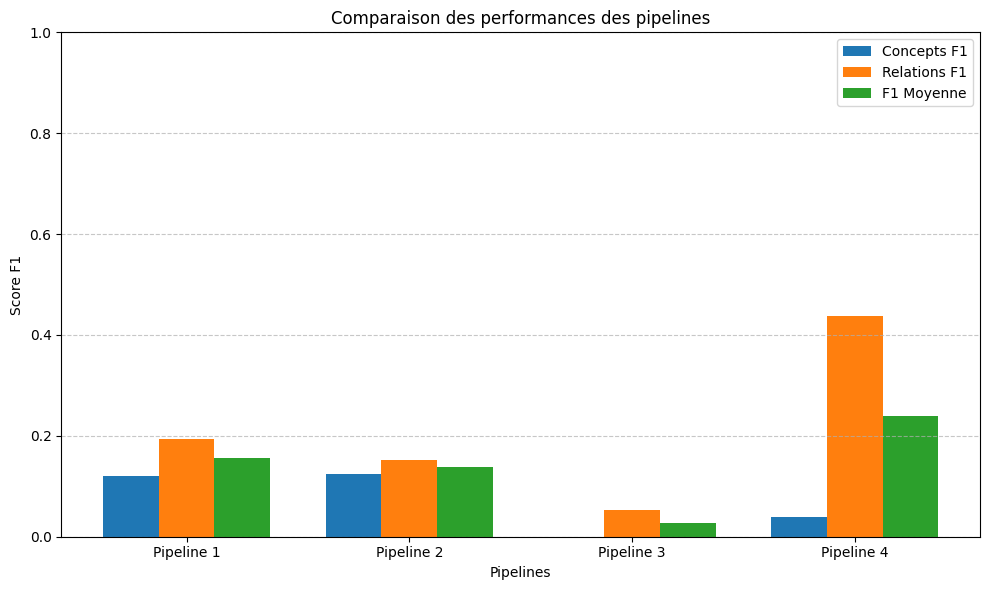

In [70]:

# Supposons que tu as ces 4 dictionnaires :
results = {
    "Pipeline 1": best_report_1,
    "Pipeline 2": best_report_2,
    "Pipeline 3": best_report_3,
    "Pipeline 4": best_report_4,
}

# Extraction des données pour chaque pipeline
pipelines = list(results.keys())
concept_f1 = [results[p]["concepts"]["f1"] for p in pipelines]
relation_f1 = [results[p]["relations"]["f1"] for p in pipelines]
avg_f1 = [results[p]["avg_f1"] for p in pipelines]

# Largeur des barres
bar_width = 0.25
x = range(len(pipelines))

# Création du plot
plt.figure(figsize=(10, 6))
plt.bar([i - bar_width for i in x], concept_f1, width=bar_width, label="Concepts F1")
plt.bar(x, relation_f1, width=bar_width, label="Relations F1")
plt.bar([i + bar_width for i in x], avg_f1, width=bar_width, label="F1 Moyenne")

# Étiquettes et légende
plt.xlabel("Pipelines")
plt.ylabel("Score F1")
plt.title("Comparaison des performances des pipelines")
plt.xticks(ticks=x, labels=pipelines)
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [71]:
data = []
for name, result in results.items():
    data.append({
        "Pipeline": name,
        "Concepts_F1": result["concepts"]["f1"],
        "Relations_F1": result["relations"]["f1"],
        "Avg_F1": result["avg_f1"]
    })

df_results = pd.DataFrame(data)

# Affichage
print(df_results)

     Pipeline  Concepts_F1  Relations_F1    Avg_F1
0  Pipeline 1     0.120000      0.194079  0.157039
1  Pipeline 2     0.123711      0.152091  0.137901
2  Pipeline 3     0.000000      0.053333  0.026667
3  Pipeline 4     0.039216      0.437736  0.238476
